<a href="https://colab.research.google.com/github/BintangPancahaya/PemMes_2026/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Langkah 1a - Import Library

In [1]:
	# import library
	import numpy as np
	import matplotlib.pyplot as plt
	from scipy import stats
	import seaborn as sns
	from sklearn.svm import SVC

Langkah 1b - Buat Kembali Fungsi Plotting

In [2]:
	# buat sebuah fungsi untuk menampilkan fitting data

	def plot_svc_decision_function(model, ax=None, plot_support=True):

	    if ax is None:
	        ax = plt.gca()
	    xlim = ax.get_xlim()
	    ylim = ax.get_ylim()

	    # buat grid untuk evaluasi model
	    x = np.linspace(xlim[0], xlim[1], 30)
	    y = np.linspace(ylim[0], ylim[1], 30)
	    Y, X = np.meshgrid(y, x)
	    xy = np.vstack([X.ravel(), Y.ravel()]).T
	    P = model.decision_function(xy).reshape(X.shape)

	    # plot batas dan margin
	    ax.contour(X, Y, P, colors='k',
	               levels=[-1, 0, 1], alpha=0.5,
	               linestyles=['--', '-', '--'])

	    # plot support vectors
	    if plot_support:
	        ax.scatter(model.support_vectors_[:, 0],
	                   model.support_vectors_[:, 1],
	                   s=300, linewidth=1, facecolors='none');
	    ax.set_xlim(xlim)
	    ax.set_ylim(ylim)

Langkah 1c - Buat Data Dummy Non-Linier

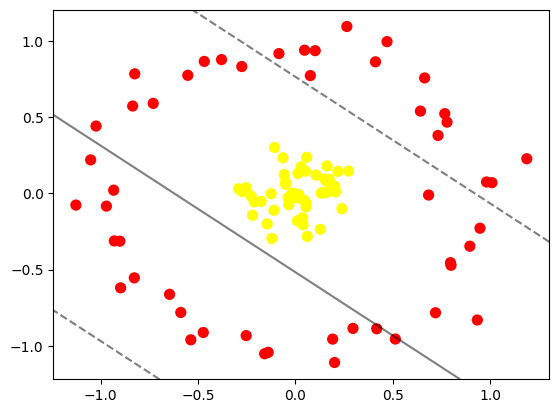

In [3]:
	# contoh data tidak terpisah secara linier
	from sklearn.datasets import make_circles
	X, y = make_circles(100, factor=.1, noise=.1)

	clf = SVC(kernel='linear').fit(X, y)

	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf, plot_support=False);

In [4]:
r = np.exp(-(X**2).sum(1))

In [5]:
	from mpl_toolkits import mplot3d
	from ipywidgets import interact, fixed

	def plot_3D(elev=30, azim=30, X=X, y=y):
	    ax = plt.subplot(projection='3d')
	    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
	    ax.view_init(elev=elev, azim=azim)
	    ax.set_xlabel('x')
	    ax.set_ylabel('y')
	    ax.set_zlabel('r')

	interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
	         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-1.20581244e-01, -2.96108277e-01],
       [-8.24326012e-01,  7.82785674e-01],
       [-1.02300183e+00,  4.40445578e-01],
       [ 1.32651989e-01,  1.80619542e-03],
       [ 2.64212340e-01,  1.09313402e+00],
       [ 3.74689090e-02, -1.59991206e-01],
       [-2.52562346e-01,  3.67538989e-02],
       [-5.88022925e-01, -7.81223204e-01],
       [ 7.69084489e-02,  7.71299194e-01],
       [-5.72065963e-02,  1.23328089e-01],
       [ 1.64107625e-01,  7.95230391e-03],
       [-5.04121913e-02,  5.93493149e-02],
       [ 4.11151095e-01,  8.61527380e-01],
       [ 2.95819489e-01, -8.85562279e-01],
       [ 2.55475640e-02, -3.30801781e-02],
       [ 5.81598405e-02,  2.35925569e-01],
       [-8.34958204e-01,  5.71886345e-01],
       [ 1.06151779e-01,  1.18627181e-01],
       [-9.00757339e-01, -3.13708649e-01],
       [-9.69894296e-01, -8.42136760e-02],
       [ 1.62341494e-01,  1.79267927e-01],
       [ 7.78393732e-01,  4.66295445e-01],
       [-1.24435145e-01, -3.03086923e-03],
       [-1.12637468e+00, -7.72403122e-02],
       [ 1.00900094e+00,  6.96200624e-02],
       [-7.91684584e-03, -1.45063267e-03],
       [ 1.50384267e-01,  9.42438484e-02],
       [ 2.01297019e-01, -1.10890127e+00],
       [ 8.95622268e-01, -3.46873485e-01],
       [ 4.73869892e-02,  9.37777173e-01],
       [-4.67451599e-01,  8.64286007e-01],
       [-3.73969664e-02, -2.84391695e-02],
       [-2.52470496e-01, -9.32648973e-01],
       [-1.10036147e-01, -1.11376798e-01],
       [ 9.47494577e-01, -2.29144501e-01],
       [ 9.33842226e-01, -8.30539179e-01],
       [-2.27098907e-01, -1.84934039e-02],
       [ 2.91576226e-02,  1.72692301e-01],
       [ 5.14527065e-02,  1.44996304e-01],
       [ 6.41951272e-01,  5.38493917e-01],
       [ 4.72552034e-02, -4.87019269e-02],
       [-8.42457047e-02,  9.15496976e-01],
       [-4.72634196e-01, -9.12502264e-01],
       [ 1.25430109e-02,  1.29816233e-01],
       [-1.76038454e-01, -5.25999268e-02],
       [-7.29610559e-01,  5.89281712e-01],
       [ 3.85629836e-04, -2.88339647e-02],
       [-9.29095186e-01, -3.12349775e-01],
       [ 6.09922302e-02, -2.82514316e-01],
       [ 1.07293778e-02, -2.47567632e-02],
       [-2.19557945e-01, -1.44506574e-01],
       [ 1.49324641e-01,  3.99719073e-03],
       [ 1.89106213e-01,  3.67223781e-02],
       [ 4.17492278e-01, -8.88054126e-01],
       [-1.57551066e-01, -1.05157941e+00],
       [-1.44759279e-01, -2.00769645e-01],
       [ 6.83759721e-01, -1.15520922e-02],
       [ 4.70320201e-01,  9.93760557e-01],
       [ 1.27649826e-01, -2.36309321e-01],
       [ 1.73621667e-01,  9.09822923e-02],
       [-2.91767605e-01,  2.96757148e-02],
       [-1.39548306e-01, -1.04250447e+00],
       [-9.32519252e-01,  2.03623045e-02],
       [ 5.13129854e-01, -9.55278267e-01],
       [ 7.98901267e-01, -4.71890872e-01],
       [-5.06001374e-02,  7.43512091e-02],
       [ 1.18778744e+00,  2.26298432e-01],
       [ 7.19185867e-01, -7.83003274e-01],
       [-2.75003053e-01,  8.30685527e-01],
       [ 2.38770753e-01, -1.01280642e-01],
       [ 7.32219324e-01,  3.78845653e-01],
       [-2.73418557e-01,  1.14708096e-02],
       [ 5.49726091e-02, -8.83514656e-02],
       [ 7.96208868e-01, -4.54826742e-01],
       [-2.11155083e-01, -5.62808168e-02],
       [ 1.91329103e-01, -9.55770147e-01],
       [-6.38747919e-02,  2.32682959e-01],
       [ 1.67160513e-02, -8.00722353e-03],
       [ 1.04921326e-02, -1.80733734e-01],
       [ 2.02739105e-01,  4.58650778e-02],
       [-1.06883998e-01,  3.00112112e-01],
       [ 9.81347269e-01,  7.40237053e-02],
       [-8.26597825e-01, -5.54332810e-01],
       [ 2.06263550e-01,  9.41904920e-03],
       [-5.52047958e-01,  7.73069042e-01],
       [-6.45643116e-01, -6.62150861e-01],
       [ 5.27999317e-02, -6.14218855e-02],
       [-3.45575436e-02, -7.48835631e-02],
       [ 3.98746474e-02, -2.06923461e-01],
       [ 2.72733579e-01,  1.45237405e-01],
       [ 6.63605333e-01,  7.55921466e-01],
       [-5.36623547e-01, -9.60413130e-01

Langkah 2 - Fitting Model

In [6]:
	clf = SVC(kernel='rbf', C=1E6)
	clf.fit(X, y)

SVC(C=1000000.0)

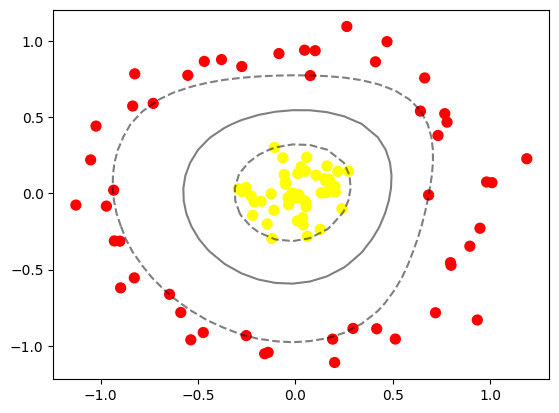

In [7]:
	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf)
	plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	            s=300, lw=1, facecolors='none')